PIP install dependencies to run Jupyter Notebook

In [54]:
!pip install --upgrade google-cloud-spanner
!pip install --upgrade google-cloud-spanner[sqlalchemy]
!pip install SQLAlchemy
!pip install --upgrade sqlalchemy-spanner
%pip install --upgrade "google-cloud-spanner[sqlalchemy]"
%pip install pandas numpy scikit-learn matplotlib pyarrow 

E0000 00:00:1752659631.381410  138171 backup_poller.cc:126] Run client channel backup poller: UNKNOWN:pollset_work {created_time:"2025-07-16T09:53:51.381314614+00:00", children:[UNKNOWN:epoll_wait: Bad file descriptor (9) {created_time:"2025-07-16T09:53:51.381153732+00:00"}]}
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


Libraries required to run Notebook

In [135]:
import os
import json
import pandas as pd
from google.cloud import spanner
from IPython.display import display
from pprint import pprint
import pandas as pd, numpy as np, datetime as dt, json, os
from pathlib import Path
from sklearn.metrics import (confusion_matrix,
    precision_recall_fscore_support, roc_auc_score,
    average_precision_score)
from datetime import datetime, timedelta

Connecting to Document Verification (DVS) Spanner Instance and Database

In [136]:
from google.cloud import spanner

PROJECT_ID = "mptinc-playground"
INSTANCE_ID = "tfgen-spanid-20250514170532172"
DATABASE_ID = "vertex-pg-database"

client = spanner.Client(project=PROJECT_ID)
instance = client.instance(INSTANCE_ID)
database = instance.database(DATABASE_ID)

print("Connected to:", database.name)

Connected to: projects/mptinc-playground/instances/tfgen-spanid-20250514170532172/databases/vertex-pg-database


SQLAlchemy connection to Spanner Database hosting instance of DVS

In [137]:
from sqlalchemy import create_engine

PROJECT_ID = "mptinc-playground"
INSTANCE_ID = "tfgen-spanid-20250514170532172"

def make_engine(db_id):
    """Engine to connect and query database"""
    return create_engine(
        f"spanner+spanner:///projects/{PROJECT_ID}/"
        f"instances/{INSTANCE_ID}/databases/{db_id}",
        isolation_level="AUTOCOMMIT"
    )


Listing all Tables within DVS database

In [126]:
from sqlalchemy import text

def list_tables(db_id: str, schema: str = "") -> None:
    """
    Print every table in "information_schema.tables for selected database
    
    Parameters
    ----------
    
    db_id : str
        The name of the target databases inside *INSTANCE_ID*
        
    Returns
    -------
    
    sqlalchemy.engine.Engine
    
    """
    sql = text(
        """
        SELECT
            table_name
        FROM
            information_schema.tables
        WHERE
            table_schema = :schema
        ORDER BY
            table_name
        """
    )
        
    engine = make_engine(db_id)
    with engine.connect() as conn:
        rows = conn.execute(sql, {"schema": schema})
        for row in rows:
            print("-", row.table_name)
if __name__ == "__main__":
    list_tables(db_id=DATABASE_ID)

/opt/conda/lib/python3.10/site-packages/google/cloud/sqlalchemy_spanner/sqlalchemy_spanner.py:1797: UserWarning: This method is non-operational as a transaction has not been started.
  dbapi_connection.rollback()


- dvs_agent
- dvs_agent_review
- dvs_customer
- dvs_verification_outcomes
- dvs_verification_steps


Listing db results from:
* dvs_verification_outcomes
* dvs_verification_steps

In [200]:
"""
Utility helpers for pulling Cloud Spanner tables into Pandas DataFrames
"""

spanner_client = spanner.Client(project=PROJECT_ID)
database = spanner_client.instance(INSTANCE_ID).database(DATABASE_ID)

def spanner_to_df(sql: str, params: dict | None = None) -> pd.DataFrame:
    """
    Execute a SQL statement on Spanenr and return results as a
    :class: `pandas.DataFrame`.
    
    Parameters
    ----------
    sql : str
    params : dict | None, optional
    
    
    Returns
    -------
    
    pandas.DataFrame
    """
    with database.snapshot() as snap:
        it = snap.execute_sql(sql, params=params or {})
        rows = list(it)
        if not rows:
            return pd.DataFrame()
        
        cols = [f.name for f in it.metadata.row_type.fields]
        return pd.DataFrame(rows, columns=cols)
    
dvs_verification_outcomes = spanner_to_df("SELECT * FROM dvs_verification_outcomes")
dvs_verification_steps = spanner_to_df("SELECT * FROM dvs_verification_steps")

pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", None)

print("dvs_verification_outcomes")
display(dvs_verification_outcomes)

print("dvs_verification_steps")
display(dvs_verification_steps)

dvs_verification_outcomes


,verification_id,dvs_correlation_id,document_reference,document_type,status,event_type,start_time,end_time,customer_id,customer_name,created_at,updated_at
0,000039e3-7e81-4235-994e-50baf5c8cc4a,test-harness-202507221329-7-10,7781c699-c130-4ce2-8d83-21a7a71b6857,ELECTRICITY,HITL Pending Review,VERIFICATION_FAILED_DVS,2025-07-22 16:03:28.319188+00:00,2025-07-22 16:03:35.009643+00:00,NGA-2025-05-0012345,NotReal Surname,2025-07-22 16:03:35.013183+00:00,2025-07-22 16:03:35.013183+00:00
1,00054042-7da6-4c3c-b40f-4b0577d2cf71,x1,4673b10c-0093-4be9-8395-9dfe140a9fc6,ELECTRICITY,HITL Pending Review,VERIFICATION_FAILED_DVS,2025-07-31 01:34:22.114985+00:00,2025-07-31 01:34:38.894600+00:00,test-clint-zzz-6,EGO MBA,2025-07-31 01:41:34.320384+00:00,2025-07-31 01:41:34.320384+00:00
2,0006a19c-5bc0-44a4-9ecb-1b140aab8f76,test-harness-202507221329-5-4,4673b10c-0093-4be9-8395-9dfe140a9fc6,ELECTRICITY,HITL Pending Review,VERIFICATION_FAILED_DVS,2025-07-22 14:50:40.411191+00:00,2025-07-22 14:50:48.226167+00:00,NGA-2025-05-0012345,NotReal Surname,2025-07-22 14:50:48.230020+00:00,2025-07-22 14:50:48.230019+00:00
3,0007236e-4bd6-44de-990c-46be4704ab07,test-harness-202507221329-8-14,a8b5906d-5792-402d-a60c-1abe66353013,ELECTRICITY,HITL Pending Review,VERIFICATION_FAILED_DVS,2025-07-22 19:31:05.346000+00:00,2025-07-22 19:31:13.006763+00:00,NGA-2025-05-0012345,NotReal Surname,2025-07-22 19:31:13.010576+00:00,2025-07-22 19:31:13.010576+00:00
4,0007c2bf-f838-4d7c-a1cb-bdb2afe80cee,test-harness-202507221329-7-22,2669443a-b94b-48ba-a889-48690b3dc891,ELECTRICITY,HITL Pending Review,VERIFICATION_FAILED_DVS,2025-07-22 17:37:48.139088+00:00,2025-07-22 17:37:54.713548+00:00,NGA-2025-05-0012345,Mercy Chukwu Compound,2025-07-22 17:37:54.717558+00:00,2025-07-22 17:37:54.717558+00:00
...,...,...,...,...,...,...,...,...,...,...,...,...
24637,fff8c8b7-c841-4d49-a5f2-e552e7d09672,test-harness-202507301620-5-7,4de177c8-df5d-43d7-9aeb-259e0469afeb,ELECTRICITY,HITL Pending Review,VERIFICATION_FAILED_DVS,2025-07-30 14:23:34.824669+00:00,2025-07-30 14:23:35.396849+00:00,NGA-2025-05-0012345,NotReal Surname,2025-07-30 14:23:35.400764+00:00,2025-07-30 14:23:35.400763+00:00
24638,fffaa1ca-1f85-4d98-bec4-eb54d9cd1276,test-harness-202507221329-8-3,3196fe06-9e85-49d8-a330-f125daeb0bbe,ELECTRICITY,HITL Pending Review,VERIFICATION_FAILED_DVS,2025-07-22 14:50:17.223634+00:00,2025-07-22 14:50:23.059747+00:00,NGA-2025-05-0012345,NotReal Surname,2025-07-22 14:50:23.184295+00:00,2025-07-22 14:50:23.184295+00:00
24639,fffc44fc-04bd-46f4-8239-48901bee3fe6,test-harness-202507221329-4-11,7d2129f4-aab4-49f9-b47a-4b3580cd6111,ELECTRICITY,HITL Pending Review,VERIFICATION_FAILED_DVS,2025-07-22 18:11:38.052946+00:00,2025-07-22 18:11:42.722447+00:00,NGA-2025-05-0012345,NotReal Surname,2025-07-22 18:11:42.726350+00:00,2025-07-22 18:11:42.726350+00:00
24640,fffd49c0-1572-4071-949a-e4d1b01be89c,test-harness-202507221329-1-13,99a4f42c-e87e-4c48-b93d-cdef414db605,ELECTRICITY,HITL Pending Review,VERIFICATION_FAILED_DVS,2025-07-22 12:43:34.708244+00:00,2025-07-22 12:43:38.971982+00:00,NGA-2025-05-0012345,NotReal Surname,2025-07-22 12:43:38.975912+00:00,2025-07-22 12:43:38.975912+00:00


dvs_verification_steps


,verification_id,step_id,step_name,start_time,end_time,step_outcome,step_output,created_at
0,000039e3-7e81-4235-994e-50baf5c8cc4a,2620bf39-4f81-4254-9576-db4e90694f05,FORGERY_DETECTION,2025-07-22 16:03:29.321759+00:00,2025-07-22 16:03:29.323338+00:00,SUCCESS,"""{\""confidence\"":0.7,\""riskLevel\"":\""MEDIUM\"",...",2025-07-22 16:03:35.036554+00:00
1,000039e3-7e81-4235-994e-50baf5c8cc4a,4d6010bd-3ff0-4d1d-8643-aa2570b6e72e,DOCUMENT_RETRIEVAL,2025-07-22 16:03:28.319240+00:00,2025-07-22 16:03:29.321623+00:00,SUCCESS,"""\""IMAGE\""""",2025-07-22 16:03:35.036542+00:00
2,000039e3-7e81-4235-994e-50baf5c8cc4a,5668266a-d25a-4c77-9536-9d3dd863f9c1,EXTERNAL_VALIDATION,2025-07-22 16:03:35.009281+00:00,2025-07-22 16:03:35.009386+00:00,ERROR,"""{\""startTime\"":[2025,7,22,16,3,35,9281912],\""...",2025-07-22 16:03:35.036561+00:00
3,000039e3-7e81-4235-994e-50baf5c8cc4a,78bc272c-b4b9-41bc-93ec-904e8b6f9f67,ENTITY_EXTRACTION,2025-07-22 16:03:32.198136+00:00,2025-07-22 16:03:35.008975+00:00,SUCCESS,"""{\""confidence\"":0.8798022866249084,\""extracte...",2025-07-22 16:03:35.036550+00:00
4,000039e3-7e81-4235-994e-50baf5c8cc4a,c4eb1b3f-91ae-4bf9-8057-987a7f1dd988,CONTENT_VALIDATION,2025-07-22 16:03:35.009304+00:00,2025-07-22 16:03:35.009484+00:00,FAILURE,"""{\""extractedFields\"":[{\""value\"":\""ILOGUN QTR...",2025-07-22 16:03:35.036557+00:00
...,...,...,...,...,...,...,...,...
147326,ffffb312-6221-4386-9ef1-56c3b264eda4,44018964-6e80-4e9d-bd21-0fc49d0a8840,EXTERNAL_VALIDATION,2025-07-22 17:38:05.684742+00:00,2025-07-22 17:38:05.684841+00:00,ERROR,"""{\""startTime\"":[2025,7,22,17,38,5,684742314],...",2025-07-22 17:38:05.712800+00:00
147327,ffffb312-6221-4386-9ef1-56c3b264eda4,5e9795f2-1ae9-43f0-8b85-00fcc1f744ba,DOCUMENT_RETRIEVAL,2025-07-22 17:38:03.225886+00:00,2025-07-22 17:38:04.183097+00:00,SUCCESS,"""\""IMAGE\""""",2025-07-22 17:38:05.712782+00:00
147328,ffffb312-6221-4386-9ef1-56c3b264eda4,8da17463-919d-40a1-8a82-fa611d42aeb8,ENTITY_EXTRACTION,2025-07-22 17:38:04.183306+00:00,2025-07-22 17:38:05.684444+00:00,SUCCESS,"""{\""confidence\"":0.9818966587384542,\""extracte...",2025-07-22 17:38:05.712789+00:00
147329,ffffb312-6221-4386-9ef1-56c3b264eda4,dd863d21-d178-4323-b0e3-0f91dca6942a,CONTENT_VALIDATION,2025-07-22 17:38:05.684779+00:00,2025-07-22 17:38:05.684912+00:00,FAILURE,"""{\""extractedFields\"":[{\""value\"":\""AJIYO IREW...",2025-07-22 17:38:05.712795+00:00


Querying dvs_correlation_id from verification_steps_outcome

In [222]:
from google.cloud import spanner
import pandas as pd

PROJECT_ID   = "mptinc-playground"
INSTANCE_ID  = "tfgen-spanid-20250514170532172"
DATABASE_ID  = "vertex-pg-database"

spanner_client = spanner.Client(project=PROJECT_ID)
database       = spanner_client.instance(INSTANCE_ID).database(DATABASE_ID)

def spanner_to_df(
        sql: str,
        params: dict | None = None,
        param_types: dict | None = None
    ) -> pd.DataFrame:
    """
    Run a SQL statement on Cloud Spanner and return the result as a DataFrame.
    """
    with database.snapshot() as snap:
        it = snap.execute_sql(
            sql,
            params=params or {},
            param_types=param_types or {},
        )
        rows = list(it)
        if not rows:
            return pd.DataFrame()

        cols = [f.name for f in it.metadata.row_type.fields]
        return pd.DataFrame(rows, columns=cols)

DVS_CORRELATION_ID = "az-harness-37"

sql_outcomes = """
SELECT *
FROM dvs_verification_outcomes
WHERE dvs_correlation_id = @corr_id
"""

params = {"corr_id": DVS_CORRELATION_ID}
param_types = {"corr_id": spanner.param_types.STRING}

dvs_verification_outcomes = spanner_to_df(sql_outcomes, params, param_types)

# # (Optional) – fetch the matching steps as well
# sql_steps = """
# SELECT *
# FROM dvs_verification_steps
# WHERE dvs_correlation_id = @corr_id
# """
# dvs_verification_steps = spanner_to_df(sql_steps, params, param_types)

# Display
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", None)

print("dvs_verification_outcomes")
display(dvs_verification_outcomes)

print("dvs_verification_steps")
display(dvs_verification_steps)


dvs_verification_outcomes


,verification_id,dvs_correlation_id,document_reference,document_type,status,event_type,start_time,end_time,customer_id,customer_name,created_at,updated_at
0,5eec8b41-9206-450a-b53f-6b2972b3f1ae,az-harness-37,57692f51-fb36-45af-a5cf-3a6d7c4aa677,ELECTRICITY,HITL Pending Review,VERIFICATION_FAILED_DVS,2025-08-06 11:42:47.710706+00:00,2025-08-06 11:43:12.001598+00:00,NGA-2025-07-25,SANI ISA,2025-08-06 11:43:12.005918+00:00,2025-08-06 11:43:12.005918+00:00
1,f9ad0fef-eb84-4d4d-8a1b-d4f6c8064110,az-harness-37,57692f51-fb36-45af-a5cf-3a6d7c4aa677,ELECTRICITY,HITL Pending Review,VERIFICATION_FAILED_DVS,2025-08-06 11:42:47.710706+00:00,2025-08-06 11:43:12.001598+00:00,NGA-2025-07-25,SANI ISA,2025-08-06 11:44:43.096110+00:00,2025-08-06 11:44:43.096109+00:00


dvs_verification_steps


,verification_id,step_id,step_name,start_time,end_time,step_outcome,step_output,created_at
0,000039e3-7e81-4235-994e-50baf5c8cc4a,2620bf39-4f81-4254-9576-db4e90694f05,FORGERY_DETECTION,2025-07-22 16:03:29.321759+00:00,2025-07-22 16:03:29.323338+00:00,SUCCESS,"""{\""confidence\"":0.7,\""riskLevel\"":\""MEDIUM\"",...",2025-07-22 16:03:35.036554+00:00
1,000039e3-7e81-4235-994e-50baf5c8cc4a,4d6010bd-3ff0-4d1d-8643-aa2570b6e72e,DOCUMENT_RETRIEVAL,2025-07-22 16:03:28.319240+00:00,2025-07-22 16:03:29.321623+00:00,SUCCESS,"""\""IMAGE\""""",2025-07-22 16:03:35.036542+00:00
2,000039e3-7e81-4235-994e-50baf5c8cc4a,5668266a-d25a-4c77-9536-9d3dd863f9c1,EXTERNAL_VALIDATION,2025-07-22 16:03:35.009281+00:00,2025-07-22 16:03:35.009386+00:00,ERROR,"""{\""startTime\"":[2025,7,22,16,3,35,9281912],\""...",2025-07-22 16:03:35.036561+00:00
3,000039e3-7e81-4235-994e-50baf5c8cc4a,78bc272c-b4b9-41bc-93ec-904e8b6f9f67,ENTITY_EXTRACTION,2025-07-22 16:03:32.198136+00:00,2025-07-22 16:03:35.008975+00:00,SUCCESS,"""{\""confidence\"":0.8798022866249084,\""extracte...",2025-07-22 16:03:35.036550+00:00
4,000039e3-7e81-4235-994e-50baf5c8cc4a,c4eb1b3f-91ae-4bf9-8057-987a7f1dd988,CONTENT_VALIDATION,2025-07-22 16:03:35.009304+00:00,2025-07-22 16:03:35.009484+00:00,FAILURE,"""{\""extractedFields\"":[{\""value\"":\""ILOGUN QTR...",2025-07-22 16:03:35.036557+00:00
...,...,...,...,...,...,...,...,...
147326,ffffb312-6221-4386-9ef1-56c3b264eda4,44018964-6e80-4e9d-bd21-0fc49d0a8840,EXTERNAL_VALIDATION,2025-07-22 17:38:05.684742+00:00,2025-07-22 17:38:05.684841+00:00,ERROR,"""{\""startTime\"":[2025,7,22,17,38,5,684742314],...",2025-07-22 17:38:05.712800+00:00
147327,ffffb312-6221-4386-9ef1-56c3b264eda4,5e9795f2-1ae9-43f0-8b85-00fcc1f744ba,DOCUMENT_RETRIEVAL,2025-07-22 17:38:03.225886+00:00,2025-07-22 17:38:04.183097+00:00,SUCCESS,"""\""IMAGE\""""",2025-07-22 17:38:05.712782+00:00
147328,ffffb312-6221-4386-9ef1-56c3b264eda4,8da17463-919d-40a1-8a82-fa611d42aeb8,ENTITY_EXTRACTION,2025-07-22 17:38:04.183306+00:00,2025-07-22 17:38:05.684444+00:00,SUCCESS,"""{\""confidence\"":0.9818966587384542,\""extracte...",2025-07-22 17:38:05.712789+00:00
147329,ffffb312-6221-4386-9ef1-56c3b264eda4,dd863d21-d178-4323-b0e3-0f91dca6942a,CONTENT_VALIDATION,2025-07-22 17:38:05.684779+00:00,2025-07-22 17:38:05.684912+00:00,FAILURE,"""{\""extractedFields\"":[{\""value\"":\""AJIYO IREW...",2025-07-22 17:38:05.712795+00:00


Explode JSON responses for for each components output and the results of each component run.
- Filters by correlation_id
- correlation_id retrieves relevant run with each components status from dvs_verification_steps
- correlation_id retrieves verification_id associated to correlation_id key, returns the component output from dvs_verification_outcomes
- Appends results of component output to the component status


In [225]:
import json
import pandas as pd
from google.cloud import spanner
from typing import Any, Dict, List

PROJECT_ID   = "mptinc-playground"
INSTANCE_ID  = "tfgen-spanid-20250514170532172"
DATABASE_ID  = "vertex-pg-database"

spanner_client = spanner.Client(project=PROJECT_ID)
database       = spanner_client.instance(INSTANCE_ID).database(DATABASE_ID)

def spanner_to_df(sql: str,
                  params: dict | None = None,
                  param_types: dict | None = None) -> pd.DataFrame:
    with database.snapshot() as snap:
        it = snap.execute_sql(sql,
                              params=params or {},
                              param_types=param_types or {})
        rows = list(it)
        if not rows:
            return pd.DataFrame()
        cols = [f.name for f in it.metadata.row_type.fields]
        return pd.DataFrame(rows, columns=cols)


def _unwrap_to_dict(txt: str, max_depth: int = 3) -> Dict[str, Any] | None:
    cur: Any = txt
    for _ in range(max_depth):
        if isinstance(cur, str):
            try:            cur = json.loads(cur)
            except json.JSONDecodeError:  return None
        else: break
    return cur if isinstance(cur, dict) else None

def _explode_step_output(df_steps: pd.DataFrame) -> pd.DataFrame:
    rows: list[dict] = []

    for _, rec in df_steps.iterrows():
        obj = _unwrap_to_dict(rec["step_output"])
        if obj is None:
            continue

        common = {
            "verification_id":    rec["verification_id"],
            "dvs_correlation_id": rec["dvs_correlation_id"],
            "step_name":          rec.get("step_name"),
            "step_strategy":      rec.get("step_strategy"),
            "page":               rec.get("page"),
            "step_outcome":       rec.get("step_outcome"),
            "start_time":         rec.get("start_time"),
            "end_time":           rec.get("end_time"),
        }

        strategy = (rec.get("step_strategy") or rec.get("step_name") or "").upper()

        if strategy == "ENTITY_EXTRACTION":
            for field in obj.get("extractedFields", []):
                rows.append({**common, **field})

        elif strategy == "CLASSIFICATION":
            candidates = (
                obj.get("classes")
                or obj.get("predictions")
                or [obj]
            )
            for cls in candidates:
                rows.append({**common, **cls})

        else:
            flat = pd.json_normalize(obj, sep=".").iloc[0].to_dict()
            rows.append({**common, **flat})

    return pd.DataFrame(rows)


def exploded_steps_for_correlation(corr_id: str) -> pd.DataFrame:
    sql_steps = """
    SELECT
        s.*,
        o.dvs_correlation_id
    FROM   `dvs_verification_steps`    AS s
    JOIN   `dvs_verification_outcomes` AS o
           ON s.verification_id = o.verification_id
    WHERE  o.dvs_correlation_id = @corr_id
    """
    params      = {"corr_id": corr_id}
    param_types = {"corr_id": spanner.param_types.STRING}

    steps = spanner_to_df(sql_steps, params, param_types)
    if steps.empty:
        return pd.DataFrame()

    return _explode_step_output(steps)

DVS_CORR_ID = "az-harness-46"
print("Connected DB:", database.name)
exploded = exploded_steps_for_correlation(DVS_CORR_ID)
display(exploded.head(50))



Connected DB: projects/mptinc-playground/instances/tfgen-spanid-20250514170532172/databases/vertex-pg-database


,verification_id,dvs_correlation_id,step_name,step_strategy,page,step_outcome,start_time,end_time,confidence,riskLevel,customerType,startTime,endTime,gammaFlag,gammaScore,dpiFlag,dpiScore,dateFlag,dateScore,strategy,error,forgery,value,label,entity,valid,documentType,strategiesExecuted,classificationOutcome,extractedFields,customerName,customerAddress,meterNumber
0,0bb713aa-2f8e-4c3d-9600-5efc57bb18db,az-harness-46,FORGERY_DETECTION,None,NaN,SUCCESS,2025-08-07 12:47:08.532871+00:00,2025-08-07 12:47:08.536341+00:00,1.00,LOW,CUSTOMER_TYPE_UNSPECIFIED,"[2025, 8, 7, 14, 47, 8, 532871156]","[2025, 8, 7, 14, 47, 8, 536341008]",False,1.0,False,0.5,False,1.0,METADATA Forgery Detection,False,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0bb713aa-2f8e-4c3d-9600-5efc57bb18db,az-harness-46,ENTITY_EXTRACTION,None,0.0,SUCCESS,2025-08-07 12:47:03.570541+00:00,2025-08-07 12:47:08.531781+00:00,0.95,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"N1,100",AMOUNT,AMOUNT,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0bb713aa-2f8e-4c3d-9600-5efc57bb18db,az-harness-46,ENTITY_EXTRACTION,None,0.0,SUCCESS,2025-08-07 12:47:03.570541+00:00,2025-08-07 12:47:08.531781+00:00,0.98,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Sun 18th May, 2025 20:40:43",TRANSACTION_DATE,TRANSACTION_DATE,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0bb713aa-2f8e-4c3d-9600-5efc57bb18db,az-harness-46,ENTITY_EXTRACTION,None,0.0,SUCCESS,2025-08-07 12:47:03.570541+00:00,2025-08-07 12:47:08.531781+00:00,0.99,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,08165548811,PHONE_NUMBER,PHONE_NUMBER,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0bb713aa-2f8e-4c3d-9600-5efc57bb18db,az-harness-46,ENTITY_EXTRACTION,None,0.0,SUCCESS,2025-08-07 12:47:03.570541+00:00,2025-08-07 12:47:08.531781+00:00,0.99,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,TUKUR,CUSTOMER_NAME,CUSTOMER_NAME,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,0bb713aa-2f8e-4c3d-9600-5efc57bb18db,az-harness-46,ENTITY_EXTRACTION,None,0.0,SUCCESS,2025-08-07 12:47:03.570541+00:00,2025-08-07 12:47:08.531781+00:00,0.98,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,36 TATARI ALI QUATERS,SERVICE_ADDRESS,SERVICE_ADDRESS,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,0bb713aa-2f8e-4c3d-9600-5efc57bb18db,az-harness-46,CLASSIFICATION,None,NaN,SUCCESS,2025-08-07 12:47:08.537400+00:00,2025-08-07 12:47:45.378756+00:00,0.80,NaN,PREPAID,"[2025, 8, 7, 14, 47, 8, 537400886]","[2025, 8, 7, 14, 47, 45, 378756869]",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,DOCUMENT_TYPE_UNSPECIFIED,[GEMINI_ONE_SHOT],CLASSIFIED,NaN,NaN,NaN,NaN
7,0bb713aa-2f8e-4c3d-9600-5efc57bb18db,az-harness-46,CONTENT_VALIDATION,None,NaN,SUCCESS,2025-08-07 12:47:45.379880+00:00,2025-08-07 12:47:45.380207+00:00,1.00,NaN,CUSTOMER_TYPE_UNSPECIFIED,"[2025, 8, 7, 14, 47, 45, 379880818]","[2025, 8, 7, 14, 47, 45, 380207797]",NaN,NaN,NaN,NaN,NaN,NaN,ALL_FIELDS_MORE_THAN_50,False,NaN,NaN,NaN,NaN,True,NaN,NaN,NaN,"[{'value': 'N1,100', 'confidence': 0.95, 'labe...",NaN,NaN,NaN
8,0bb713aa-2f8e-4c3d-9600-5efc57bb18db,az-harness-46,EXTERNAL_VALIDATION,None,NaN,ERROR,2025-08-07 12:47:45.379324+00:00,2025-08-07 12:47:45.379522+00:00,0.00,NaN,NaN,"[2025, 8, 7, 14, 47, 45, 379324664]","[2025, 8, 7, 14, 47, 45, 379522599]",NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Entity Extraction**

This section quantifies entity extraction performance by measuring performance criteria
- Average confidence score across all entities extracted
- Number of valid entities per document, that meets confidence thresholds
- Total entities extracted per document

Deserializing ENTITY_EXTRACTION JSON results to list entities extracted
* Deserializes step_output from dvs_verification_steps

In [201]:
"""
Helper for unwrapping nested JSON blobs in step records, 
flattens the **ENTITY_EXTRACTION** into
:class:`pandas.DataFrame`
"""

import json, pandas as pd, numpy as np

def _unwrap_to_dict(txt: str) -> dict | None:
    """Convert layers of JSON-encoded string into python ``dict``.
    
    Parameters
    ----------
    
    txt: str
    
    Returns
    -------
    dict | None
    """
    cur = txt
    for _ in range(3):
        if isinstance(cur, str):
            try:
                cur = json.loads(cur)
            except json.JSONDecodeError:
                return None
        else:
            break
    return cur if isinstance(cur, dict) else None

def explode_entity_extraction(df: pd.DataFrame) -> pd.DataFrame:
    """
    Flatten rows where ``ENITY_EXTRACTION`` into one row per extracted field
    
    Parameters
    ----------
    
    df : pandas.DataFrame
    
    Returns
    -------
    
    pandas.DataFrame
    """
    rows = []
    for _, rec in df.iterrows():
        if rec.get("step_name") != "ENTITY_EXTRACTION":
            continue

        data = _unwrap_to_dict(rec["step_output"])
        if not data:
            continue

        for item in data.get("extractedFields", []):
            rows.append({
                "verification_id": rec["verification_id"],
                "step_name":       rec["step_name"],
                "entity":          item.get("entity") or item.get("label"),
                "value":           item.get("value"),
                "confidence":      item.get("confidence"),
                "valid":           item.get("valid"),
            })
    return pd.DataFrame(rows)

wanted_id = "6b39e2a0-d4d6-402f-83c6-d4a44682df06"

steps_expanded = explode_entity_extraction(
    dvs_verification_steps.query("verification_id == @wanted_id")
)

print(f"rows exploded: {len(steps_expanded):,}")
display(steps_expanded.head(50))


rows exploded: 6


,verification_id,step_name,entity,value,confidence,valid
0,6b39e2a0-d4d6-402f-83c6-d4a44682df06,ENTITY_EXTRACTION,AMOUNT,"N1,100",0.95,True
1,6b39e2a0-d4d6-402f-83c6-d4a44682df06,ENTITY_EXTRACTION,TRANSACTION_DATE,"Sun 18th May, 2025 20:40:43",0.98,True
2,6b39e2a0-d4d6-402f-83c6-d4a44682df06,ENTITY_EXTRACTION,CUSTOMER_NAME,TUKUR,0.95,True
3,6b39e2a0-d4d6-402f-83c6-d4a44682df06,ENTITY_EXTRACTION,PHONE_NUMBER,08165548811,0.97,True
4,6b39e2a0-d4d6-402f-83c6-d4a44682df06,ENTITY_EXTRACTION,SERVICE_ADDRESS,36 TATARI ALI QUATERS,0.94,False
5,6b39e2a0-d4d6-402f-83c6-d4a44682df06,ENTITY_EXTRACTION,ACCOUNT_NUMBER,0150000890718,0.96,True


In [198]:
subset = dvs_verification_steps.query(
    "verification_id == '6b39e2a0-d4d6-402f-83c6-d4a44682df06'"
)
print(f"rows with that ID: {len(subset):,}")
display(subset.head())


rows with that ID: 0


,verification_id,step_id,step_name,start_time,end_time,step_outcome,step_output,created_at


In [209]:
def explode_entity_extraction_entity_label(
    df: pd.DataFrame,
    target_entity: str | None = None,
) -> pd.DataFrame:
    """
    Flatten ENTITY_EXTRACTION rows into one row per extracted field.

    If *target_entity* is provided (e.g. "PROVIDER_ACRONYM"), only rows whose
    ``entity``/``label`` match (case-insensitive) are returned.
    """
    rows: list[dict] = []

    for _, rec in df.iterrows():
        if rec.get("step_name") != "ENTITY_EXTRACTION":
            continue

        data = _unwrap_to_dict(rec["step_output"])
        if not data:
            continue

        for item in data.get("extractedFields", []):
            entity = (item.get("entity") or item.get("label") or "").upper()

            # skip if this row is not the entity we want
            if target_entity and entity != target_entity.upper():
                continue

            rows.append({
                "verification_id": rec["verification_id"],
                "step_name":       rec["step_name"],
                "entity":          entity,
                "value":           item.get("value"),
                "confidence":      item.get("confidence"),
                "valid":           item.get("valid"),
            })

    return pd.DataFrame(rows)

steps_expanded = explode_entity_extraction_entity_label(dvs_verification_steps)


provider_acronym_df = explode_entity_extraction_entity_label(
    dvs_verification_steps,
    target_entity="PROVIDER_ACRONYM",
)

acronym_counts = (
    provider_acronym_df["value"]
    .dropna()
    .str.strip()
    .value_counts()
)
# print(f"Distinct provider acronyms: {len(distinct_acronym_count):,}")
for acro, cnt in acronym_counts.items():
    print(f"{acro:<17} {cnt}")
print(f"provider-acronym rows: {len(provider_acronym_df):,}")
display(provider_acronym_df.head(20))


KADUNA ELECTRIC   770
IBEDC             747
AEDC              549
YEDC              525
JED PLC           437
KEDCO             418
BEDC              413
ke                248
PHED              227
PH                194
JOS ELECTRICITY DISTRIBUTION PLC 165
KADUNA            113
JOS               110
JAJI AO           107
WEMA              86
JED PIc           79
JED               74
KE                71
JOS ELECTRICITY DISTRIBUTION PLO 53
JOS ELECTRICITY   51
Port Harcourt Electricity Distribution Company 48
JED PIC           42
JED Plc           32
enugudisco        26
HOME STEEL        23
None              19
GU ELECTRI        16
C1TC-NMD          11
PH-Gamma1-T1B     9
KADUNA
ELECTRIC   9
ENUGU ELECTRICITY DISTRIBUTION COMPANY 7
ENUGU ELECTRICITY 6
INEC              6
PalmPay           5
Port Harcourt Electricity 5
ENUGU DISCO       3
ENUGUDISCO        3
G-PAY             3
E - Non MD        2
DISCO             2
E                 2
NERC              2
Port Harcourt     2
ENUGU     

,verification_id,step_name,entity,value,confidence,valid
0,0006a19c-5bc0-44a4-9ecb-1b140aab8f76,ENTITY_EXTRACTION,PROVIDER_ACRONYM,JED PIc,0.95,False
1,0007236e-4bd6-44de-990c-46be4704ab07,ENTITY_EXTRACTION,PROVIDER_ACRONYM,BEDC,0.95,False
2,0026b7b7-a981-48ec-a4fd-fc150ceab789,ENTITY_EXTRACTION,PROVIDER_ACRONYM,AEDC,0.98,True
3,002aca1e-8ecd-4317-9cd3-bcdfd8233565,ENTITY_EXTRACTION,PROVIDER_ACRONYM,KEDCO,0.99,True
4,0037a49a-cade-4113-ad09-eb347e4bd9ba,ENTITY_EXTRACTION,PROVIDER_ACRONYM,JAJI AO,0.98,True
5,004d5d35-d760-47fb-bd0e-6b04d8c34d27,ENTITY_EXTRACTION,PROVIDER_ACRONYM,KADUNA ELECTRIC,0.95,False
6,004e8e73-b409-4d72-9b6a-3c3c032af1fb,ENTITY_EXTRACTION,PROVIDER_ACRONYM,YEDC,0.98,True
7,00569e4a-347a-41e4-ba6b-d2c8ceafdf6d,ENTITY_EXTRACTION,PROVIDER_ACRONYM,IBEDC,0.98,True
8,0064585e-49df-4d31-9aef-339a2e3f4962,ENTITY_EXTRACTION,PROVIDER_ACRONYM,IBEDC,0.99,True
9,006d74e3-ea54-47cc-b76e-04b29c10a995,ENTITY_EXTRACTION,PROVIDER_ACRONYM,YEDC,0.98,True


In [62]:
def compute_document_metrics(dvs_verification_steps: pd.DataFrame) -> pd.DataFrame:
    """
    Aggregate entity extraction qualify metrics

    Workflow
    --------

    1. Calls explode entity extraction to expand each entity into a row
    2. Groups by verfication_id and dervice
        * average confidence
        * valid entities
        * total entities
    3. Computes proportion of valid entities
    4. Returns the tidy metric dataframe

    Parameters
    ----------
    dvs_verification_steps: pandas DataFrame

    Returns
    -------
    pandas.DataFrame
        Columns:
        ``verification_id``
        ``avg_confidence``
        ``prop_valid``
        ``total_entities``
    """
    fields_df = explode_entity_extraction(dvs_verification_steps)

    doc_metrics = (
        fields_df
            .groupby("verification_id")
            .agg(
                avg_confidence = ("confidence", "mean"),
                valid_entities = ("valid", "sum"),
                total_entities = ("valid", "size")
            )
        .reset_index()
    )
    
    doc_metrics["prop_valid"] = doc_metrics["valid_entities"] / doc_metrics["total_entities"]
    
    doc_metrics = doc_metrics[["verification_id",
                               "avg_confidence", 
                               "prop_valid",
                               "total_entities"
                              ]]
    
    doc_metrics[["avg_confidence", "prop_valid"]] = doc_metrics[["avg_confidence",
                                                                 "prop_valid"]].round(3)
    
    return doc_metrics

display(compute_document_metrics(dvs_verification_steps))


,verification_id,avg_confidence,prop_valid,total_entities
0,0003cdc1-bef7-4ff3-8176-cc589e5c6708,0.929,0.684,307
1,000c9c29-ac81-4d46-aa6f-57c418f097b4,0.962,0.893,28
2,000f2db2-b077-4cdd-95cd-1f70fd007465,0.977,0.833,12
3,00193c8b-47fc-4660-a93c-61d8a8050911,0.939,0.705,193
4,001be062-d43c-43ed-88ab-1131ae1d34c4,0.950,0.000,1
...,...,...,...,...
3558,ff899dc3-0c5a-4085-8257-c093c7d72b48,0.962,0.893,28
3559,ff956017-0e23-4118-85b9-63c9d7f635f6,0.954,0.751,301
3560,ffe64be1-1123-4f00-b556-15df1fae6f65,0.962,0.893,28
3561,fffd0f08-454d-47ea-87af-f4ccc763832e,0.962,0.893,28


**Document Classification**

_This section of the notebook performs extractions and evaluation of the Document Classification component of the DVS System_:
- Deserialising Classification JSON response from dvs_verification_steps
- Creates two datasets for evaluation: classification results and classification results with ground truth labels
- Creates a predictive peformance measure of the classification outcomes

Deserialising DOCUMENT_ClASSIFICATION JSON results to list document classification outcome
* Deserialises step_output from dvs_verification_steps

In [63]:
"""
Helper for normalising **CLASSIFICATION** outcomes
into a flat :class:`pandas.DataFrame`.
"""
def _unwrap_to_dict(txt: str) -> dict | None:
    """Unwrap JSON-encoded string into python ``dict``.
    
    Parameters
    ----------
    txt: str
    
    Returns
    -------
    dict | None
    """
    cur = txt
    for _ in range(3):
        if isinstance(cur, str):
            try:
                cur = json.loads(cur)
            except json.JSONDecodeError:
                return None
        else:
            break
    return cur if isinstance(cur, dict) else None

def _arr_to_ts(arr):
    """
    Convert Cloud-Spanner style [Y,M,D,H,M,S,nanos] arrays
    into a pandas Timestamp.
    
    Parameters
    ----------
    arr : list | tuple
    
    Returns
    -------
    pandas.Timestamp | pandas.NaT
    """
    if not arr or len(arr) < 7:
        return pd.NaT
    try:
        base = datetime(*arr[:6])
        return pd.Timestamp(base) + timedelta(microseconds=arr[6] / 1_000)
    except (TypeError, ValueError):
        return pd.NaT

def explode_classification(df: pd.DataFrame) -> pd.DataFrame:
    """
    Flatten rows with ``step_name`` as **CLASSIFICATION** into one record
    per ``verification_id``
    
    Parameters
    ----------
    
    df : pandas.DataFrame
    
    Returns
    -------
    pandas.DataFrame
    """
    out_rows = []

    cls_mask = df["step_name"] == "CLASSIFICATION"
    for _, rec in df[cls_mask].iterrows():
        data = _unwrap_to_dict(rec["step_output"])
        if not data:
            continue

        start_ts = _arr_to_ts(data.get("startTime"))
        end_ts   = _arr_to_ts(data.get("endTime"))
        duration = (
            (end_ts - start_ts).total_seconds()
            if pd.notna(start_ts) and pd.notna(end_ts)
            else np.nan
        )

        out_rows.append({
            "verification_id":        rec["verification_id"],
            "confidence":             data.get("confidence"),
            "customer_type":          data.get("customerType"),
            "document_type":          data.get("documentType"),
            "strategies_executed":    data.get("strategiesExecuted", []),
            "classification_outcome": data.get("classificationOutcome"),
            "start_time":             start_ts,
            "end_time":               end_ts,
            "duration_seconds":       duration,
        })

    return pd.DataFrame(out_rows)
display(explode_classification(dvs_verification_steps))

,verification_id,confidence,customer_type,document_type,strategies_executed,classification_outcome,start_time,end_time,duration_seconds
0,0003cdc1-bef7-4ff3-8176-cc589e5c6708,1.00,PREPAID,ELECTRICITY,[ENTITY_BASED],CLASSIFIED,2025-07-14 13:02:01.376000,2025-07-14 13:02:01.376060,0.000060
1,000c9c29-ac81-4d46-aa6f-57c418f097b4,1.00,PREPAID,ELECTRICITY,[ENTITY_BASED],CLASSIFIED,2025-07-08 14:13:08.386786,2025-07-08 14:13:08.387335,0.000549
2,000f2db2-b077-4cdd-95cd-1f70fd007465,0.95,PREPAID,ELECTRICITY,[GEMINI_ONE_SHOT],CLASSIFIED,2025-07-14 11:41:22.821624,2025-07-14 11:41:25.685741,2.864117
3,00193c8b-47fc-4660-a93c-61d8a8050911,0.95,PREPAID,ELECTRICITY,[GEMINI_ONE_SHOT],CLASSIFIED,2025-07-14 13:10:28.382015,2025-07-14 13:10:30.976170,2.594155
4,001be062-d43c-43ed-88ab-1131ae1d34c4,0.99,PREPAID,DOCUMENT_TYPE_UNSPECIFIED,[GEMINI_ONE_SHOT],CLASSIFIED,2025-07-14 13:03:49.820614,2025-07-14 13:03:52.306606,2.485992
...,...,...,...,...,...,...,...,...,...
3462,ff899dc3-0c5a-4085-8257-c093c7d72b48,1.00,PREPAID,ELECTRICITY,[ENTITY_BASED],CLASSIFIED,2025-07-11 09:00:02.487955,2025-07-11 09:00:02.488034,0.000079
3463,ff956017-0e23-4118-85b9-63c9d7f635f6,1.00,PREPAID,ELECTRICITY,[ENTITY_BASED],CLASSIFIED,2025-07-14 12:47:29.886390,2025-07-14 12:47:29.886434,0.000044
3464,ffe64be1-1123-4f00-b556-15df1fae6f65,1.00,PREPAID,ELECTRICITY,[ENTITY_BASED],CLASSIFIED,2025-07-11 09:41:24.211163,2025-07-11 09:41:24.211349,0.000186
3465,fffd0f08-454d-47ea-87af-f4ccc763832e,1.00,PREPAID,ELECTRICITY,[ENTITY_BASED],CLASSIFIED,2025-07-08 13:43:29.081218,2025-07-08 13:43:29.081369,0.000151


In [78]:
def get_steps_for_correlation(corr_id: str) -> pd.DataFrame:
    sql = """
        SELECT s.*                                -- or o.*, s.* if you also need outcome columns
        FROM   dvs_verification_steps   AS s
        JOIN   dvs_verification_outcomes AS o
          ON   s.verification_id = o.verification_id
        WHERE  o.dvs_correlation_id = @corr_id
    """
    return spanner_to_df(sql, params={"corr_id": corr_id})

corr_id = "az-harness-202507141413-6-22"     # the target dvs_correlation_id
steps_df = get_steps_for_correlation(corr_id)
display(steps_df)

,verification_id,step_id,step_name,start_time,end_time,step_outcome,step_output,created_at
0,0354f779-0a05-43b5-b349-423f8da14a87,705433e7-cb3d-4530-8156-c3fe8eaf0a9b,DOCUMENT_RETRIEVAL,2025-07-15 07:34:54.490499+00:00,2025-07-15 07:35:12.576802+00:00,SUCCESS,"""\""IMAGE\""""",2025-07-15 07:46:07.262775+00:00
1,0354f779-0a05-43b5-b349-423f8da14a87,a9470692-411e-4329-800f-e8a8a5a24818,ENTITY_EXTRACTION,2025-07-15 07:35:12.577442+00:00,2025-07-15 07:35:16.648006+00:00,SUCCESS,"""{\""confidence\"":0.95,\""extractedFields\"":[{\""...",2025-07-15 07:46:07.262869+00:00
2,0354f779-0a05-43b5-b349-423f8da14a87,b4448eca-8465-459a-9511-4c2c06115195,FORGERY_DETECTION,2025-07-15 07:35:12.577456+00:00,2025-07-15 07:35:12.586399+00:00,SUCCESS,"""{\""confidence\"":0.7,\""riskLevel\"":\""MEDIUM\"",...",2025-07-15 07:46:07.262904+00:00
3,13251e38-1c38-431e-964a-27180e6805f4,007b479c-caf3-4dc3-aaa3-eee50391b6aa,CONTENT_VALIDATION,2025-07-16 08:24:31.416885+00:00,2025-07-16 08:24:31.417142+00:00,SUCCESS,"""{\""extractedFields\"":[],\""confidence\"":0.0,\""...",2025-07-16 08:24:44.685408+00:00
4,13251e38-1c38-431e-964a-27180e6805f4,46b7aa33-c7fe-4dcd-adb6-ef77c23a60ff,EXTERNAL_VALIDATION,2025-07-16 08:24:31.416816+00:00,2025-07-16 08:24:31.417070+00:00,ERROR,"""{\""startTime\"":[2025,7,16,10,24,31,416816146]...",2025-07-16 08:24:44.685491+00:00
5,13251e38-1c38-431e-964a-27180e6805f4,6e2a822c-2d95-4dd3-b830-e20de9206570,ENTITY_EXTRACTION,2025-07-16 08:24:16.224844+00:00,2025-07-16 08:24:20.409125+00:00,ERROR,"""{\""confidence\"":0.0,\""extractedFields\"":[],\""...",2025-07-16 08:24:44.685273+00:00
6,13251e38-1c38-431e-964a-27180e6805f4,b418159e-97cc-4051-9cc9-dcf4a48e330a,CLASSIFICATION,2025-07-16 08:24:31.416604+00:00,2025-07-16 08:24:40.740042+00:00,ERROR,"""{\""confidence\"":0.0,\""customerType\"":\""PREPAI...",2025-07-16 08:24:44.685453+00:00
7,13251e38-1c38-431e-964a-27180e6805f4,ba3cc43c-542f-4965-a808-957241c215b2,DOCUMENT_RETRIEVAL,2025-07-16 08:24:04.558665+00:00,2025-07-16 08:24:16.223996+00:00,SUCCESS,"""\""IMAGE\""""",2025-07-16 08:24:44.685182+00:00
8,13251e38-1c38-431e-964a-27180e6805f4,f85b62bd-6032-484c-b3f8-77688a214137,FORGERY_DETECTION,2025-07-16 08:24:16.224846+00:00,2025-07-16 08:24:16.227501+00:00,SUCCESS,"""{\""confidence\"":0.7,\""riskLevel\"":\""MEDIUM\"",...",2025-07-16 08:24:44.685314+00:00
9,1dd623ce-0b7d-4aba-8e78-99cccf772424,1a8b2923-b679-4089-8b66-8f90a32320bc,ENTITY_EXTRACTION,2025-07-16 09:36:29.467269+00:00,2025-07-16 09:36:39.337469+00:00,ERROR,"""{\""confidence\"":0.0,\""extractedFields\"":[],\""...",2025-07-16 09:38:39.971301+00:00


In [79]:
print(steps_df.columns.tolist())

['verification_id', 'step_id', 'step_name', 'start_time', 'end_time', 'step_outcome', 'step_output', 'created_at']


In [88]:

import json
from datetime import datetime, timedelta
import numpy as np
import pandas as pd

def spanner_to_df(sql: str, params: dict | None = None) -> pd.DataFrame:
    """
    Run a SQL statement on Spanner and return a DataFrame
    that always carries the correct column headers.
    """
    with database.snapshot() as snap:
        it   = snap.execute_sql(sql, params=params or {})
        rows = list(it)
        cols = [f.name for f in it.metadata.row_type.fields]
        return pd.DataFrame(rows, columns=cols)

def get_steps_for_correlation(corr_id: str) -> pd.DataFrame:
    sql = """
        SELECT s.*
        FROM   dvs_verification_steps   AS s
        JOIN   dvs_verification_outcomes AS o
          ON   s.verification_id = o.verification_id
        WHERE  o.dvs_correlation_id = @corr_id
    """
    return spanner_to_df(sql, params={"corr_id": corr_id})

def _canonicalise_step_cols(df: pd.DataFrame) -> pd.DataFrame:
    """
    Rename any plausible alias of step_name / step_output into the exact
    labels the flattener expects.  Raises a clear KeyError if a match
    cannot be found.
    """
    df = df.copy()
    lc_cols = {c.lower(): c for c in df.columns}

    step_name_aliases   = ["step_name", "name", "step"]
    step_output_aliases = ["step_output", "output", "stepoutput"]

    rename = {}
    for alias in step_name_aliases:
        if alias in lc_cols:
            rename[lc_cols[alias]] = "step_name"
            break
    for alias in step_output_aliases:
        if alias in lc_cols:
            rename[lc_cols[alias]] = "step_output"
            break

    if "step_name" not in rename.values():
        raise KeyError(f"Couldn’t find column {step_name_aliases} in {list(df.columns)}")
    if "step_output" not in rename.values():
        raise KeyError(f"Couldn’t find column {step_output_aliases} in {list(df.columns)}")

    return df.rename(columns=rename)

def _unwrap_to_dict(txt: str) -> dict | None:
    """Safely JSON-decode, unwrapping extra quotes if needed."""
    cur = txt
    for _ in range(3):
        if isinstance(cur, str):
            try:
                cur = json.loads(cur)
            except json.JSONDecodeError:
                return None
        else:
            break
    return cur if isinstance(cur, dict) else None

def _arr_to_ts(arr):
    """Cloud-Spanner [Y,M,D,H,M,S,nanos] → pandas.Timestamp."""
    if not arr or len(arr) < 7:
        return pd.NaT
    try:
        base = datetime(*arr[:6])
        return pd.Timestamp(base) + timedelta(microseconds=arr[6] / 1_000)
    except (TypeError, ValueError):
        return pd.NaT

def explode_classification(df: pd.DataFrame) -> pd.DataFrame:
    """
    Flatten CLASSIFICATION rows to one tidy record per verification_id.
    Expects columns 'step_name' and 'step_output' (canonicalised).
    """
    rows = []

    cls_rows = df[df["step_name"].str.upper() == "CLASSIFICATION"]

    for _, rec in cls_rows.iterrows():
        data = _unwrap_to_dict(rec["step_output"])
        if not data:
            continue

        start_ts = _arr_to_ts(data.get("startTime"))
        end_ts   = _arr_to_ts(data.get("endTime"))
        duration = (
            (end_ts - start_ts).total_seconds()
            if pd.notna(start_ts) and pd.notna(end_ts)
            else np.nan
        )

        rows.append({
            "verification_id":        rec["verification_id"],
            "confidence":             data.get("confidence"),
            "customer_type":          data.get("customerType"),
            "document_type":          data.get("documentType"),
            "strategies_executed":    data.get("strategiesExecuted", []),
            "classification_outcome": data.get("classificationOutcome"),
            "start_time":             start_ts,
            "end_time":               end_ts,
            "duration_seconds":       duration,
        })

    return pd.DataFrame(rows)


corr_id = "az-harness-202507141413-6-22"

steps_df = get_steps_for_correlation(corr_id)

if steps_df.empty:
    print(f" No verification steps found for correlation_id = {corr_id!r}")
else:
    steps_df = _canonicalise_step_cols(steps_df)
    cls_df   = explode_classification(steps_df)

    outcome_df = dvs_verification_outcomes
    final = (
        outcome_df[outcome_df["dvs_correlation_id"] == corr_id]
          .merge(cls_df, on="verification_id", how="left")
    )

    print("Flattened CLASSIFICATION block:")
    display(cls_df.head())

    print("\nOutcome + flattened data:")
    display(final.head())


Flattened CLASSIFICATION block:


,verification_id,confidence,customer_type,document_type,strategies_executed,classification_outcome,start_time,end_time,duration_seconds
0,13251e38-1c38-431e-964a-27180e6805f4,0.00,PREPAID,DOCUMENT_TYPE_UNSPECIFIED,[GEMINI_ONE_SHOT],FAILED,2025-07-16 10:24:31.416605,2025-07-16 10:24:40.740042,9.323437
1,1dd623ce-0b7d-4aba-8e78-99cccf772424,0.00,PREPAID,DOCUMENT_TYPE_UNSPECIFIED,[GEMINI_ONE_SHOT],FAILED,2025-07-16 11:37:17.541137,2025-07-16 11:37:56.760498,39.219361
2,3f713114-531e-492b-af7f-cbaa2d42d4db,0.95,PREPAID,DOCUMENT_TYPE_UNSPECIFIED,[GEMINI_ONE_SHOT],CLASSIFIED,2025-07-16 11:52:33.971027,2025-07-16 11:52:54.042008,20.070981
3,590a8a6c-0187-412b-8348-468d0fd2ea2a,0.95,PREPAID,DOCUMENT_TYPE_UNSPECIFIED,[GEMINI_ONE_SHOT],CLASSIFIED,2025-07-16 11:52:33.971027,2025-07-16 11:52:54.042008,20.070981
4,877d8625-2889-4fc6-82d5-c3485a36375d,0.95,PREPAID,DOCUMENT_TYPE_UNSPECIFIED,[GEMINI_ONE_SHOT],CLASSIFIED,2025-07-15 09:32:14.299844,2025-07-15 09:32:36.031839,21.731995



Outcome + flattened data:


,verification_id,dvs_correlation_id,document_reference,document_type_x,status,event_type,start_time_x,end_time_x,customer_id,customer_name,created_at,updated_at,confidence,customer_type,document_type_y,strategies_executed,classification_outcome,start_time_y,end_time_y,duration_seconds
0,0354f779-0a05-43b5-b349-423f8da14a87,az-harness-202507141413-6-22,99a4f42c-e87e-4c48-b93d-cdef414db605,ELECTRICITY,HITL In Review,VERIFICATION_FAILED_DVS,2025-07-15 07:34:54.490033+00:00,2025-07-15 07:46:04.931732+00:00,NGA-2025-05-0012345,IDOWU OPESA,2025-07-15 07:46:06.085363+00:00,2025-07-15 07:46:06.085362+00:00,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN
1,13251e38-1c38-431e-964a-27180e6805f4,az-harness-202507141413-6-22,99a4f42c-e87e-4c48-b93d-cdef414db605,ELECTRICITY,HITL In Review,VERIFICATION_FAILED_DVS,2025-07-16 08:24:04.557976+00:00,2025-07-16 08:24:43.949065+00:00,NGA-2025-05-0012345,IDOWU OPESA,2025-07-16 08:24:43.954982+00:00,2025-07-16 08:24:43.954981+00:00,0.00,PREPAID,DOCUMENT_TYPE_UNSPECIFIED,[GEMINI_ONE_SHOT],FAILED,2025-07-16 10:24:31.416605,2025-07-16 10:24:40.740042,9.323437
2,1dd623ce-0b7d-4aba-8e78-99cccf772424,az-harness-202507141413-6-22,99a4f42c-e87e-4c48-b93d-cdef414db605,ELECTRICITY,HITL In Review,VERIFICATION_FAILED_DVS,2025-07-16 09:35:23.042274+00:00,2025-07-16 09:38:39.152649+00:00,NGA-2025-05-0012345,IDOWU OPESA,2025-07-16 09:38:39.173182+00:00,2025-07-16 09:38:39.173181+00:00,0.00,PREPAID,DOCUMENT_TYPE_UNSPECIFIED,[GEMINI_ONE_SHOT],FAILED,2025-07-16 11:37:17.541137,2025-07-16 11:37:56.760498,39.219361
3,590a8a6c-0187-412b-8348-468d0fd2ea2a,az-harness-202507141413-6-22,99a4f42c-e87e-4c48-b93d-cdef414db605,ELECTRICITY,HITL In Review,VERIFICATION_FAILED_DVS,2025-07-16 09:51:52.062620+00:00,2025-07-16 09:53:20.282924+00:00,NGA-2025-05-0012345,IDOWU OPESA,2025-07-16 09:53:20.289295+00:00,2025-07-16 09:53:20.289295+00:00,0.95,PREPAID,DOCUMENT_TYPE_UNSPECIFIED,[GEMINI_ONE_SHOT],CLASSIFIED,2025-07-16 11:52:33.971027,2025-07-16 11:52:54.042008,20.070981
4,5b98756a-a454-436a-833b-ecf43f1747fd,az-harness-202507141413-6-22,99a4f42c-e87e-4c48-b93d-cdef414db605,ELECTRICITY,HITL In Review,VERIFICATION_FAILED_DVS,2025-07-15 07:34:54.490033+00:00,2025-07-15 07:46:04.931732+00:00,NGA-2025-05-0012345,IDOWU OPESA,2025-07-15 07:53:43.521701+00:00,2025-07-15 07:53:43.521700+00:00,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN


In [76]:
az-harness-202507141413-6-22

[]


Creating functions for the creation of DataFrames for Classification Outcome Analysis and Evaluation.
Steps include: 
- Creation of dataset used for evaluation and analysis
- Creation of dataset as set of ground truth to perform evaluation on

In [64]:
def build_log_dataframe(cls_df: pd.DataFrame) -> pd.DataFrame:
    """
    Convert the exploded *CLASSIFICATION* dataframe into a flat
    **prediction-log** table that the evaluation pipeline expects.

    Parameters
    ----------
    cls_df : pandas.DataFrame
        Output of :func:`explode_classification`. Must contain at least
        the columns

        * ``verification_id`` – unique document key
        * ``confidence`` – model confidence (0-1) or NaN for rule-based hits
        * ``document_type`` – classifier’s hard prediction
        * ``strategies_executed`` – list of strategies that ran
        * ``classification_outcome`` – SUCCESS / FAILED
        * ``start_time`` / ``end_time`` – execution timestamps
        * ``duration_seconds`` – execution latency in seconds

    Returns
    -------
    pandas.DataFrame
        Normalised prediction log with the canonical column schema
        used by the metric notebook::*.
    """
    log = (
        cls_df
        .assign(method=lambda x: x["strategies_executed"].str[0])
        .rename(columns={
            "verification_id": "id",
            "confidence":      "score",
            "document_type":   "predicted_class",
            "classification_outcome": "status",
            "start_time":      "start_ts",
            "end_time":        "end_ts",
            "duration_seconds":"latency_s",
        })
        [["id", "score", "customer_type",
          "predicted_class", "method", "status",
          "start_ts", "end_ts", "latency_s"]]
        .sort_values("start_ts")
    )
    return log


def build_gold_labels(cls_df: pd.DataFrame) -> pd.DataFrame:
    """
    Extract the human-verified **ground-truth labels** from the exploded
    classification dataframe.

    This helper is only correct if *document_type* already reflects the
    *true* class (e.g. because every document has been manually reviewed
    and fixed).  If your workflow stores gold labels elsewhere, replace
    this function with a database query or file read.

    Parameters
    ----------
    cls_df : pandas.DataFrame
        Same input used for :func:`build_log_dataframe`.

    Returns
    -------
    pandas.DataFrame
        Two-column table with the schema required by the evaluator::

            id          – document key (matches prediction log)
            true_class  – ground-truth document class
    """
    gold = (
        cls_df[["verification_id", "document_type"]]
        .rename(columns={
            "verification_id": "id",
            "document_type":   "true_class",
        })
    )
    return gold


Writing datasets for evaluation and ground truths to CSV files for analysis

In [68]:
cls_df = explode_classification(dvs_verification_steps)

"""
build_log_dataframe() -> Writes CLASSIFICATION outcome to csv for analysis

build_gold_labels() -> Writes document with Ground Truths for evaluation and analysis.
"""
log  = build_log_dataframe(cls_df)
log.to_csv("doc_classification_logs.csv", index=False)
print(f"wrote {len(log)} prediction rows")

"""Do not run this again"""
gold = build_gold_labels(cls_df)
gold.to_csv("ground_truth_labels.csv", index=False)
print(f"wrote gold labels for {len(gold)} documents")

wrote 3467 prediction rows
wrote gold labels for 3467 documents


Merging Classification Outcomes with Ground Truth Labels
- Merging on document id

In [69]:
"""
Fetches document classification results and ground truth labels to be merged together
"""

log  = pd.read_csv("doc_classification_logs.csv",
                   parse_dates=["start_ts","end_ts"])
gold = pd.read_csv("ground_truth_labels.csv")

df = log.merge(gold, on="id", how="inner")
assert not df.empty, "No overlap between predictions and labels!"

pprint(df.head(3).to_dict(orient="records"))

[{'customer_type': 'PREPAID',
  'end_ts': Timestamp('2025-07-07 12:07:34.447824'),
  'id': '5c5e4c0e-2cd3-4739-81a0-6989809c61ac',
  'latency_s': 12.654268,
  'method': 'GEMINI_ONE_SHOT',
  'predicted_class': 'DOCUMENT_TYPE_UNSPECIFIED',
  'score': 0.0,
  'start_ts': Timestamp('2025-07-07 12:07:21.793556'),
  'status': 'FAILED',
  'true_class': 'DOCUMENT_TYPE_UNSPECIFIED'},
 {'customer_type': 'PREPAID',
  'end_ts': Timestamp('2025-07-08 09:29:25.230133'),
  'id': 'f51d0ef8-473d-4b5c-b65c-069929ca4c98',
  'latency_s': 0.000535,
  'method': 'ENTITY_BASED',
  'predicted_class': 'ELECTRICITY',
  'score': 1.0,
  'start_ts': Timestamp('2025-07-08 09:29:25.229598'),
  'status': 'CLASSIFIED',
  'true_class': 'ELECTRICITY'},
 {'customer_type': 'PREPAID',
  'end_ts': Timestamp('2025-07-08 09:46:47.329355'),
  'id': '80d50502-9c8e-4e63-b20a-32864c6b786e',
  'latency_s': 5.341924,
  'method': 'GEMINI_ONE_SHOT',
  'predicted_class': 'DOCUMENT_TYPE_UNSPECIFIED',
  'score': 0.0,
  'start_ts': Timesta

Building Performance Metrics for Classification Outcomes.

Creates measures for the following from Classification Outcomes and Ground Truth:
- TP, TN, FP, FN meaures
- Precision
- Recall
- F1-Score
- Average Precision
- Mean Latency

In [70]:
"""
Compute binary-classification metrics for each distinct method

The routine:

1. Creates binary target column ``y_true_bin``
2. Converts the model ``score`` into hard prediction at the 0.50 threshold
3. Calculates
    * Precision, recall, F1-score
    * Extracts confusion matrix (tn, fp, fn, tp)
4. Records mean inference latency

Returns
-------
pandas.DataFrame
"""

results = []

POS_LABEL = "ELECTRICITY"

df["y_true_bin"] = (df["true_class"] == POS_LABEL).astype(int)

for method, sub in df.groupby("method"):
    y_true  = sub["y_true_bin"]
    scores  = sub["score"].fillna(1.0)
    y_pred  = (scores >= 0.50).astype(int)

    prec, rec, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="binary", zero_division=0
    )

    tn, fp, fn, tp = confusion_matrix(
        y_true, y_pred, labels=[0, 1]
    ).ravel()

    if y_true.nunique() == 2 and scores.nunique() > 1:
        roc_auc = roc_auc_score(y_true, scores)
        ap      = average_precision_score(y_true, scores)
    else:
        roc_auc = None
        ap      = None

    results.append({
        "method": method,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "tn": tn, "fp": fp, "fn": fn, "tp": tp,
        "roc_auc": roc_auc,
        "avg_precision": ap,
        "mean_latency_s": sub["latency_s"].mean(),
    })

metrics_df = pd.DataFrame(results)
display(metrics_df)


,method,precision,recall,f1,tn,fp,fn,tp,roc_auc,avg_precision,mean_latency_s
0,ENTITY_BASED,1.000000,1.0,1.000000,170,0,0,1604,1.00000,1.000000,0.047222
1,GEMINI_ONE_SHOT,0.882109,1.0,0.937362,5,199,0,1489,0.53539,0.890854,2.499768


**Forgery Detection**

  This section of the notebook performs extractions and evaluation of the Forgery Detection component of the DVS System:

- Deserialising Classification JSON response from dvs_verification_steps
- Create snapshot of metadata captured in Forgery Detection Outcomes, metadata and associated flags.

Measure how it behaves as population:

- Proportion of documents flagged as fraud
- Pinpoint internal drift in checks performed on gamma, DPI, and date.
- Confidence distribution, indicating how sure detector is about forged documents
- Latency, how long processing and P95 latency detection

Deserialising FORGERY_DETECTION JSON results to list forgery heuristic outcome
* Deserialises step_output from dvs_verification_steps

In [24]:
"""
Helper for flattening **FORGERY_DETECTION** into analysis ready
:class:`pandas.DataFrame
"""

import pandas as pd
import numpy as np
from datetime import datetime, timedelta

def explode_forgery_detection(df: pd.DataFrame) -> pd.DataFrame:
    """
    Convert rows with ``step_name`` as **FORGERY_DETECTION** into
    flat table
    
    Parameters
    ----------
    df : pandas.DataFrame
    
    Returns
    -------
    pandas.DataFrame
    """
    out_rows = []

    mask = df["step_name"] == "FORGERY_DETECTION"
    for _, rec in df[mask].iterrows():
        data = _unwrap_to_dict(rec["step_output"])
        if not data:
            continue

        start_ts = _arr_to_ts(data.get("startTime"))
        end_ts   = _arr_to_ts(data.get("endTime"))
        duration_sec = (
            (end_ts - start_ts).total_seconds()
            if pd.notna(start_ts) and pd.notna(end_ts)
            else np.nan
        )

        out_rows.append({
            "verification_id":  rec["verification_id"],
            "confidence":       data.get("confidence"),
            "risk_level":       data.get("riskLevel"),
            "customer_type":    data.get("customerType"),

            "gamma_flag":       data.get("gammaFlag"),
            "gamma_score":      data.get("gammaScore"),
            "dpi_flag":         data.get("dpiFlag"),
            "dpi_score":        data.get("dpiScore"),
            "date_flag":        data.get("dateFlag"),
            "date_score":       data.get("dateScore"),

            "forgery":          data.get("forgery"),

            "start_time":       start_ts,
            "end_time":         end_ts,
            "duration_seconds": duration_sec,
        })

    return pd.DataFrame(out_rows)


display(explode_forgery_detection(dvs_verification_steps))

,verification_id,confidence,risk_level,customer_type,gamma_flag,gamma_score,dpi_flag,dpi_score,date_flag,date_score,forgery,start_time,end_time,duration_seconds
0,00a9b507-0ac3-43a5-b623-94041de0cd20,0.96,RISK_LEVEL_UNSPECIFIED,CUSTOMER_TYPE_UNSPECIFIED,None,NaN,None,NaN,None,NaN,False,2025-07-02 11:30:49.314882,2025-07-02 11:30:50.314887,1.000005
1,0147080b-c524-44b9-b9c3-13cfb48da790,0.96,RISK_LEVEL_UNSPECIFIED,CUSTOMER_TYPE_UNSPECIFIED,None,NaN,None,NaN,None,NaN,False,2025-07-04 15:06:39.101051,2025-07-04 15:06:40.101051,1.000000
2,02a916f1-d0c6-4be8-ae86-22d229cf649b,0.96,RISK_LEVEL_UNSPECIFIED,CUSTOMER_TYPE_UNSPECIFIED,None,NaN,None,NaN,None,NaN,False,2025-07-04 15:10:26.425671,2025-07-04 15:10:27.425671,1.000000
3,03eff8bd-0940-49ef-a623-c3896e88f234,0.96,RISK_LEVEL_UNSPECIFIED,CUSTOMER_TYPE_UNSPECIFIED,None,NaN,None,NaN,None,NaN,False,2025-07-04 15:14:13.687948,2025-07-04 15:14:14.687948,1.000000
4,043ebb20-3d5e-4d9c-adf5-1e24e4a7cd09,0.96,RISK_LEVEL_UNSPECIFIED,CUSTOMER_TYPE_UNSPECIFIED,None,NaN,None,NaN,None,NaN,False,2025-06-30 10:57:59.908906,2025-06-30 10:58:00.908906,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
299,fccf3bff-2d46-4040-8a53-12a2551830a4,0.96,RISK_LEVEL_UNSPECIFIED,CUSTOMER_TYPE_UNSPECIFIED,None,NaN,None,NaN,None,NaN,False,2025-07-04 15:24:02.593783,2025-07-04 15:24:03.593784,1.000001
300,fdfdf492-7c24-4d32-b002-30b5e8018128,0.96,RISK_LEVEL_UNSPECIFIED,CUSTOMER_TYPE_UNSPECIFIED,None,NaN,None,NaN,None,NaN,False,2025-07-03 03:05:43.775208,2025-07-03 03:05:44.775208,1.000000
301,fe36752b-e309-4a69-90c2-59cf52c21892,0.96,RISK_LEVEL_UNSPECIFIED,CUSTOMER_TYPE_UNSPECIFIED,None,NaN,None,NaN,None,NaN,False,2025-06-26 06:57:07.640284,2025-06-26 06:57:08.640284,1.000000
302,fe4aaebd-17fa-437c-85e8-ed62de0a57b9,0.70,MEDIUM,CUSTOMER_TYPE_UNSPECIFIED,True,0.0,False,0.5,False,0.5,True,2025-07-01 16:07:42.212536,2025-07-01 16:07:42.214284,0.001748


Create logging configuration to log metadata from document to use as gold standard measure for the forgery detection

In [42]:
"""
Directories to store logging information on Forgery Detection
"""
BASE            = Path("./forgery_monitor")
LOG_DIR         = BASE / "logs"          ; LOG_DIR.mkdir(parents=True, exist_ok=True)
REVIEW_DIR      = BASE / "review"        ; REVIEW_DIR.mkdir(exist_ok=True)
DATA_DIR        = BASE / "data"          ; DATA_DIR.mkdir(exist_ok=True)

LABEL_FILE      = DATA_DIR / "forgery_labels.csv"
METRICS_FILE    = DATA_DIR / "forgery_daily_metrics.csv"


Writing results to logs for Forgery Detection

In [44]:
"""
Writing forgery detection metadata results to logs
"""

fd_df = explode_forgery_detection(dvs_verification_steps)

today = dt.date.today().strftime("%Y%m%d")
log_csv = LOG_DIR / f"forgery_detection_logs-{today}.csv"

(
    fd_df
    .rename(columns={"verification_id": "doc_id"})
    .to_csv(log_csv, index=False)
)

print(f"wrote {len(fd_df)} forgery-detection rows to {log_csv}")

wrote 304 forgery-detection rows to forgery_monitor/logs/forgery_detection_logs-20250709.csv


Creating statistical metrics for extracted metadata from document.

Statistical measures include:

- Date extracted
- Total flag rates and flag rates for: gamma, and dpi
- confidence quantiles
- latency quantile

In [32]:
"""
log-file summariser and rolling history keeper

Steps
-----
1. Load today's log from *log_csv* into a DataFrame
2. Derive one-row summary
3. Append and create a CSV metric history
"""

log = pd.read_csv(log_csv)

metric_row = {
    "date": str(today),
    "n_docs": len(log),
    "flag_rate": log["forgery"].mean(),
    "gamma_flag_rate": log["gamma_flag"].mean(),
    "dpi_flag_rate": log["dpi_flag"].mean(),
    "date_flag_rate": log["date_flag"].mean(),
    "conf_mean": log["confidence"].mean(),
    "conf_p05": log["confidence"].quantile(0.05),
    "conf_p95": log["confidence"].quantile(0.95),
    "latency_p95": log["duration_seconds"].quantile(0.95),
}

if METRICS_FILE.exists():
    history = pd.read_csv(METRICS_FILE, dtype={"date": str})
    history = history[history["date"] != metric_row["date"]]
else:
    history = pd.DataFrame()
    
history = pd.concat([history, pd.DataFrame([metric_row])],
                    ignore_index=True)


history["date_dt"] = pd.to_datetime(history["date"], format="%Y%m%d")
history.sort_values("date_dt", inplace=True)
history.drop(columns="date_dt", inplace=True)

history.to_csv(METRICS_FILE, index=False)

display(history.tail(7))


,date,n_docs,flag_rate,gamma_flag_rate,dpi_flag_rate,date_flag_rate,conf_mean,conf_p05,conf_p95,latency_p95
0,20250706,304,0.128289,1.0,0.029412,0.043478,0.923849,0.7,0.96,1.000005
1,20250707,304,0.128289,1.0,0.029412,0.043478,0.923849,0.7,0.96,1.000005


Plotting forgery detection flags statisical measure

,date,n_docs,flag_rate,gamma_flag_rate,dpi_flag_rate,date_flag_rate,conf_mean,conf_p05,conf_p95,latency_p95
0,20250706,304,0.128289,1.0,0.029412,0.043478,0.923849,0.7,0.96,1.000005


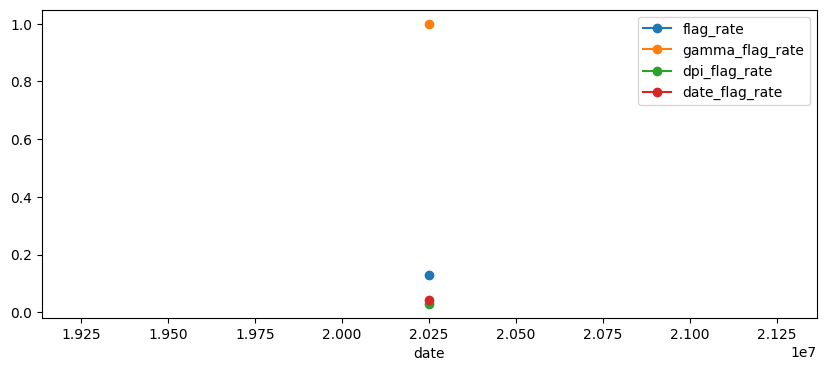

In [51]:
"""
Plotting resuls from ``METRICS_FILE`` to display flag rates of metadata captured
"""

if METRICS_FILE.exists():
    hist = pd.read_csv(METRICS_FILE)
    display(hist.tail(14))                # last two weeks
    hist.plot(x="date", y=["flag_rate", "gamma_flag_rate",
                           "dpi_flag_rate", "date_flag_rate"],
              figsize=(10,4), marker="o")

**Content Validation**

For Content Validation we peroform the following actions:
- Deserialise JSON responses from database
- Compare Entity Extraction to Content Validation results

Deserialising CONTENT_VALIDATION JSON results to list content validation outcomes
* Deserialises step_output from dvs_verification_steps

In [13]:
import pandas as pd
import numpy as np
# keep:
#   _unwrap_to_dict(txt)  -> dict|None
#   _arr_to_ts(arr)       -> pd.Timestamp|pd.NaT

def explode_content_validation(df: pd.DataFrame) -> pd.DataFrame:
    """
    Flatten CONTENT_VALIDATION-step JSON.

    For every `extractedFields[i]` item you get:
        verification_id
        label, entity, value, page
        field_confidence, field_valid          (from the item)
        step_confidence, overall_valid         (from the envelope)
        customer_type
        start_time, end_time, duration_seconds
    """
    out = []

    mask = df["step_name"] == "CONTENT_VALIDATION"
    for _, rec in df[mask].iterrows():
        data = _unwrap_to_dict(rec["step_output"])
        if not data:
            continue

        start_ts = _arr_to_ts(data.get("startTime"))
        end_ts   = _arr_to_ts(data.get("endTime"))
        duration = (
            (end_ts - start_ts).total_seconds()
            if pd.notna(start_ts) and pd.notna(end_ts)
            else np.nan
        )

        env = {
            "verification_id": rec["verification_id"],
            "step_confidence": data.get("confidence"),
            "overall_valid":   data.get("valid"),
            "customer_type":   data.get("customerType"),
            "start_time":      start_ts,
            "end_time":        end_ts,
            "duration_seconds":duration,
        }

        for itm in data.get("extractedFields", []):
            out.append({
                **env,
                "label":           itm.get("label"),
                "entity":          itm.get("entity"),
                "value":           itm.get("value"),
                "page":            itm.get("page"),
                "field_confidence":itm.get("confidence"),
                "field_valid":     itm.get("valid"),
            })

    return pd.DataFrame(out)

display(explode_content_validation(dvs_verification_steps))

,verification_id,step_confidence,overall_valid,customer_type,start_time,end_time,duration_seconds,label,entity,value,page,field_confidence,field_valid
0,00a9b507-0ac3-43a5-b623-94041de0cd20,0.090909,False,PREPAID,2025-07-02 11:30:54.845006,2025-07-02 11:30:54.847955,0.002949,AMOUNT,AMOUNT,100.00,0,0.95,False
1,00a9b507-0ac3-43a5-b623-94041de0cd20,0.090909,False,PREPAID,2025-07-02 11:30:54.845006,2025-07-02 11:30:54.847955,0.002949,METER_NUMBER,METER_NUMBER,0124001115953,0,0.98,True
2,00a9b507-0ac3-43a5-b623-94041de0cd20,0.090909,False,PREPAID,2025-07-02 11:30:54.845006,2025-07-02 11:30:54.847955,0.002949,PROVIDER_ACRONYM,PROVIDER_ACRONYM,Port Harcourt Electricity Distribution Company,0,0.97,True
3,00a9b507-0ac3-43a5-b623-94041de0cd20,0.090909,False,PREPAID,2025-07-02 11:30:54.845006,2025-07-02 11:30:54.847955,0.002949,TRANSACTION_DATE,TRANSACTION_DATE,xyzutc,0,0.85,False
4,00a9b507-0ac3-43a5-b623-94041de0cd20,0.090909,False,PREPAID,2025-07-02 11:30:54.845006,2025-07-02 11:30:54.847955,0.002949,CUSTOMER_NAME,CUSTOMER_NAME,MRS EGO MBA,0,0.90,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
796,fe36752b-e309-4a69-90c2-59cf52c21892,0.000000,False,PREPAID,2025-06-26 06:57:17.460604,2025-06-26 06:57:17.468143,0.007539,PROVIDER_ACRONYM,PROVIDER_ACRONYM,AEDC,0,0.94,False
797,fe36752b-e309-4a69-90c2-59cf52c21892,0.000000,False,PREPAID,2025-06-26 06:57:17.460604,2025-06-26 06:57:17.468143,0.007539,SERVICE_ADDRESS,SERVICE_ADDRESS,"MYPA ROAD, BOSSO Und St. Bosso",0,0.95,False
798,fe36752b-e309-4a69-90c2-59cf52c21892,0.000000,False,PREPAID,2025-06-26 06:57:17.460604,2025-06-26 06:57:17.468143,0.007539,TRANSACTION_DATE,TRANSACTION_DATE,29/10/2024,0,0.98,True
799,fe36752b-e309-4a69-90c2-59cf52c21892,0.000000,False,PREPAID,2025-06-26 06:57:17.460604,2025-06-26 06:57:17.468143,0.007539,SUPPLY_ADDRESS,SUPPLY_ADDRESS,"MYPA ROAD, BOSSO",0,0.95,False


Entity Extraction steps that match to Content Validation

In [15]:
ee_df = explode_entity_extraction(dvs_verification_steps)
cv_df = explode_content_validation(dvs_verification_steps)

comparison = (
    ee_df
    .merge(
        cv_df,
        on=["verification_id", "entity"],
        how="inner",
        suffixes=("_ex", "_cv"))
    .assign(values_equal=lambda d: d["value_ex"] == d["value_cv"])
)
    
print(f"{len(comparison):,} matched fields")
display(comparison.head(20))
    

1,223 matched fields


,verification_id,step_name,entity,value_ex,confidence,valid,step_confidence,overall_valid,customer_type,start_time,end_time,duration_seconds,label,value_cv,page,field_confidence,field_valid,values_equal
0,00a9b507-0ac3-43a5-b623-94041de0cd20,ENTITY_EXTRACTION,AMOUNT,100.00,0.95,False,0.090909,False,PREPAID,2025-07-02 11:30:54.845006,2025-07-02 11:30:54.847955,0.002949,AMOUNT,100.00,0,0.95,False,True
1,00a9b507-0ac3-43a5-b623-94041de0cd20,ENTITY_EXTRACTION,AMOUNT,100.00,0.95,False,0.090909,False,PREPAID,2025-07-02 11:30:54.845006,2025-07-02 11:30:54.847955,0.002949,AMOUNT,N100.00,0,0.95,False,False
2,00a9b507-0ac3-43a5-b623-94041de0cd20,ENTITY_EXTRACTION,AMOUNT,100.00,0.95,False,0.090909,False,PREPAID,2025-07-02 11:30:54.845006,2025-07-02 11:30:54.847955,0.002949,AMOUNT,N100.00,0,0.95,False,False
3,00a9b507-0ac3-43a5-b623-94041de0cd20,ENTITY_EXTRACTION,AMOUNT,N100.00,0.95,False,0.090909,False,PREPAID,2025-07-02 11:30:54.845006,2025-07-02 11:30:54.847955,0.002949,AMOUNT,100.00,0,0.95,False,False
4,00a9b507-0ac3-43a5-b623-94041de0cd20,ENTITY_EXTRACTION,AMOUNT,N100.00,0.95,False,0.090909,False,PREPAID,2025-07-02 11:30:54.845006,2025-07-02 11:30:54.847955,0.002949,AMOUNT,N100.00,0,0.95,False,True
5,00a9b507-0ac3-43a5-b623-94041de0cd20,ENTITY_EXTRACTION,AMOUNT,N100.00,0.95,False,0.090909,False,PREPAID,2025-07-02 11:30:54.845006,2025-07-02 11:30:54.847955,0.002949,AMOUNT,N100.00,0,0.95,False,True
6,00a9b507-0ac3-43a5-b623-94041de0cd20,ENTITY_EXTRACTION,AMOUNT,N100.00,0.95,False,0.090909,False,PREPAID,2025-07-02 11:30:54.845006,2025-07-02 11:30:54.847955,0.002949,AMOUNT,100.00,0,0.95,False,False
7,00a9b507-0ac3-43a5-b623-94041de0cd20,ENTITY_EXTRACTION,AMOUNT,N100.00,0.95,False,0.090909,False,PREPAID,2025-07-02 11:30:54.845006,2025-07-02 11:30:54.847955,0.002949,AMOUNT,N100.00,0,0.95,False,True
8,00a9b507-0ac3-43a5-b623-94041de0cd20,ENTITY_EXTRACTION,AMOUNT,N100.00,0.95,False,0.090909,False,PREPAID,2025-07-02 11:30:54.845006,2025-07-02 11:30:54.847955,0.002949,AMOUNT,N100.00,0,0.95,False,True
9,00a9b507-0ac3-43a5-b623-94041de0cd20,ENTITY_EXTRACTION,METER_NUMBER,0124001115953,0.98,True,0.090909,False,PREPAID,2025-07-02 11:30:54.845006,2025-07-02 11:30:54.847955,0.002949,METER_NUMBER,0124001115953,0,0.98,True,True


In [16]:

ex_df = explode_entity_extraction(dvs_verification_steps)
cv_df = explode_content_validation(dvs_verification_steps)

merged = (
    ex_df
    .merge(
        cv_df,
        on=["verification_id", "entity"],
        how="outer",
        suffixes=("_ex", "_cv")
    )
)

merged["in_extraction"] = merged["value_ex"].notna()
merged["in_validation"] = merged["value_cv"].notna()
merged["values_equal"]  = merged["in_extraction"] & merged["in_validation"] \
                          & (merged["value_ex"] == merged["value_cv"])


matches    = merged[ merged["values_equal"] ]
mismatches = merged[ ~merged["values_equal"] ]

print("All joined rows :", len(merged))
print("Perfect matches :", len(matches))
print("Non-matches     :", len(mismatches))

table = px.data_table(
    mismatches,
    filter_action="native",
    sort_action="native",
    page_size=25,
    fixed_rows={"headers": True},
    height=450,
)

table.show()
# display(mismatches.head())


All joined rows : 1419
Perfect matches : 833
Non-matches     : 586


NameError: name 'px' is not defined

In [ ]:
sql_metrics_start_end_time = """
    SELECT 
        verification_id, 
        event_type,
        start_time, 
        end_time, 
        TIMESTAMP_DIFF(end_time, start_time, SECOND) as duration_s
    FROM
        dvs_verification_outcomes
    ORDER BY
        event_type,
        start_time
"""

spanner_to_df(sql_metrics_start_end_time)